# 課題と解答例：1次元フィン

元Notebook：[1次元フィン](../11_stegosaurus_heat_1d_fin.ipynb)

上から順に実行できる．課題に必要な基準関数もこのNotebookに含める．

## 課題：関数の実装と検証

1. `fin_summary(target_mL_values)` を作り，`mL`，対応する `L`，`Q_fin`，`eta` をDataFrameで返す．`[0.1, 1, 3, 10]` で実行する．ここでは `k, h, P, A_c, theta_b` を固定して長さだけを変える．
2. `compare_h_values(h_values)` を作り，長さを固定して `h` を変えたときの `m`，`mL`，`Q_fin`，`eta` を表にする．温度分布を1枚の図に重ね，`h` ごとに `m` を再計算する．
3. `h` を2倍にしたときの放熱量と効率の変化を確認する．計算した `Q_fin` が，別に計算した `sqrt(h*P*k*A_c)*theta_b*tanh(m*L)` と一致することを `np.testing.assert_allclose` で検証する．
4. `fin_grid_study(n_values)` を作り，温度の相対最大誤差，根元微分と側面積分から求めた放熱量の相対誤差，温度の観測収束次数を返す．`[21, 41, 81, 161]` で実行する．最初の格子では収束次数を定義できないため `NaN` とする．

## 解答例の準備

以下は元Notebookと同じ物性値と基準関数である．

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from IPython.display import display

k     = 20.0    # thermal conductivity [W/(m K)]
h     = 25.0    # convection coefficient [W/(m^2 K)]
T_b   = 40.0    # base temperature [degC]
T_air = 25.0    # air temperature [degC]
width = 0.30    # width [m]
thick = 0.03    # thickness [m]
L     = 0.40    # length [m]

A_c = width * thick
P = 2 * (width + thick)
m = np.sqrt(h * P / (k * A_c))
theta_b = T_b - T_air
print(f'm = {m:.3f} [1/m], mL = {m*L:.3f}, Bi_perp = {h*A_c/(P*k):.4f}')


def theta_analytic(x, L, m, theta_b):
    x = np.asarray(x)
    # cosh(m*(L-x))/cosh(m*L) と等価な式で，指数のオーバーフローを避ける．
    return theta_b * (np.exp(-m*x) + np.exp(-m*(2*L-x))) / (1 + np.exp(-2*m*L))


def theta_fd(L, m, theta_b, n=101):
    if L <= 0 or m < 0 or n < 3:
        raise ValueError('Require L > 0, m >= 0, n >= 3')
    x = np.linspace(0, L, n)
    dx = x[1] - x[0]
    A = np.zeros((n, n))
    b = np.zeros(n)
    A[0, 0] = 1.0
    b[0] = theta_b
    for i in range(1, n - 1):
        A[i, i - 1] = 1.0
        A[i, i] = -2.0 - (m * dx)**2
        A[i, i + 1] = 1.0
    # 補助点 theta[n] = theta[n-2] を先端の差分式へ代入する．
    A[-1, -2] = 2.0
    A[-1, -1] = -2.0 - (m * dx)**2
    return x, np.linalg.solve(A, b)


def Q_fin(L, m, theta_b, k, A_c):
    # k*A_c*m = sqrt(h*P*k*A_c)．h を変える場合は m を再計算する．
    # 関数の外にある h を参照しない．
    return k * A_c * m * theta_b * np.tanh(m * L)


x = np.linspace(0, L, 101)
theta_exact = theta_analytic(x, L, m, theta_b)
x_fd, theta_num = theta_fd(L, m, theta_b)
print('max temperature error [K] =', np.max(np.abs(theta_num - theta_exact)))

m = 9.574 [1/m], mL = 3.830, Bi_perp = 0.0170
max temperature error [K] = 0.00034369870776895795


## 関数の実装例

,mL,L [m],Q_fin [W],eta
0,0.1,0.010445,2.576471,0.996680
1,1.0,0.104447,19.687614,0.761594
2,3.0,0.313340,25.722695,0.331685
3,10.0,1.044466,25.850532,0.100000


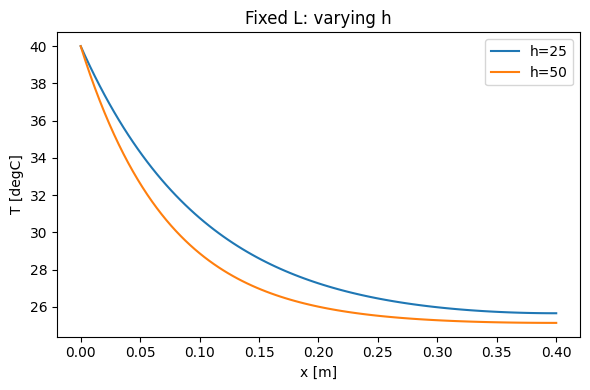

,h,m,mL,Q_fin [W],eta
0,25.0,9.574271,3.829708,25.826162,0.26087
1,50.0,13.540064,5.416026,36.556728,0.18463


,n,dx,relative T error,relative Q_base error,relative Q_side error,observed T order
0,21,0.0200,0.000570,0.012098,0.004562,NaN
1,41,0.0100,0.000143,0.003227,0.001142,1.993832
2,81,0.0050,0.000036,0.000833,0.000286,1.998822
3,161,0.0025,0.000009,0.000212,0.000071,1.999554


In [2]:
def fin_summary(target_mL_values):
    rows = []
    for target in target_mL_values:
        length = target / m
        rows.append({'mL': target, 'L [m]': length,
                     'Q_fin [W]': Q_fin(length, m, theta_b, k, A_c),
                     'eta': np.tanh(target)/target})
    return pd.DataFrame(rows)


def compare_h_values(h_values):
    rows = []
    fig, ax = plt.subplots(figsize=(6, 4))
    for h_value in h_values:
        m_value = np.sqrt(h_value*P/(k*A_c))
        q_value = Q_fin(L, m_value, theta_b, k, A_c)
        q_check = np.sqrt(h_value*P*k*A_c)*theta_b*np.tanh(m_value*L)
        np.testing.assert_allclose(q_value, q_check)
        rows.append({'h': h_value, 'm': m_value, 'mL': m_value*L,
                     'Q_fin [W]': q_value, 'eta': np.tanh(m_value*L)/(m_value*L)})
        ax.plot(x, T_air+theta_analytic(x, L, m_value, theta_b), label=f'h={h_value:g}')
    ax.set(xlabel='x [m]', ylabel='T [degC]', title='Fixed L: varying h')
    ax.legend()
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(rows)


def fin_grid_study(n_values):
    rows = []
    q_exact = Q_fin(L, m, theta_b, k, A_c)
    for n in n_values:
        xx, tt = theta_fd(L, m, theta_b, n=n)
        dx = xx[1]-xx[0]
        err = np.max(np.abs(tt-theta_analytic(xx, L, m, theta_b)))/theta_b
        q_base = -k*A_c*(-3*tt[0]+4*tt[1]-tt[2])/(2*dx)
        q_side = h*P*trapezoid(tt, xx)
        rows.append({'n': n, 'dx': dx, 'relative T error': err,
                     'relative Q_base error': abs(q_base-q_exact)/q_exact,
                     'relative Q_side error': abs(q_side-q_exact)/q_exact})
    table = pd.DataFrame(rows).sort_values('dx', ascending=False).reset_index(drop=True)
    table['observed T order'] = np.log(table['relative T error'].shift(1)/table['relative T error']) / np.log(table['dx'].shift(1)/table['dx'])
    return table


display(fin_summary([0.1, 1, 3, 10]))
display(compare_h_values([h, 2*h]))
display(fin_grid_study([21, 41, 81, 161]))

長さだけを増すと放熱量は増えて飽和し，効率は下がる．長さを固定して `h` を2倍にすると放熱量は増え，効率は下がる．温度誤差の観測収束次数は約2へ近づく．放熱量の関数が元の `h` を参照していないことも，別式との一致によって確認している．